In [316]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Education	Env.        Satisfaction	    Job Involvement	    Job Satisfaction
# 1: Below College	    1: Low              	1: Low	             1: Low
# 2: College	         2: Medium	            2: Medium	         2: Medium
# 3: Bachelor	        3: High	                3: High	             3: High
# 4: Master	            4: Very High	        4: Very High	     4: Very High
# 5: Doctor

In [ ]:
# Performance Rating	Rel. Satisfaction	Work-Life Balance
# 1: Low	            1: Low	            1: Bad
# 2: Good	            2: Medium	        2: Good
# 3: Excellent	        3: High     	    3: Better
# 4: Outstanding	    4: Very High	    4: Best

In [317]:
df = pd.read_csv("../data/HR-Employee-Attrition.csv")

In [318]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [319]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Data Analysis

In [320]:
df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### Correlation Heatmap


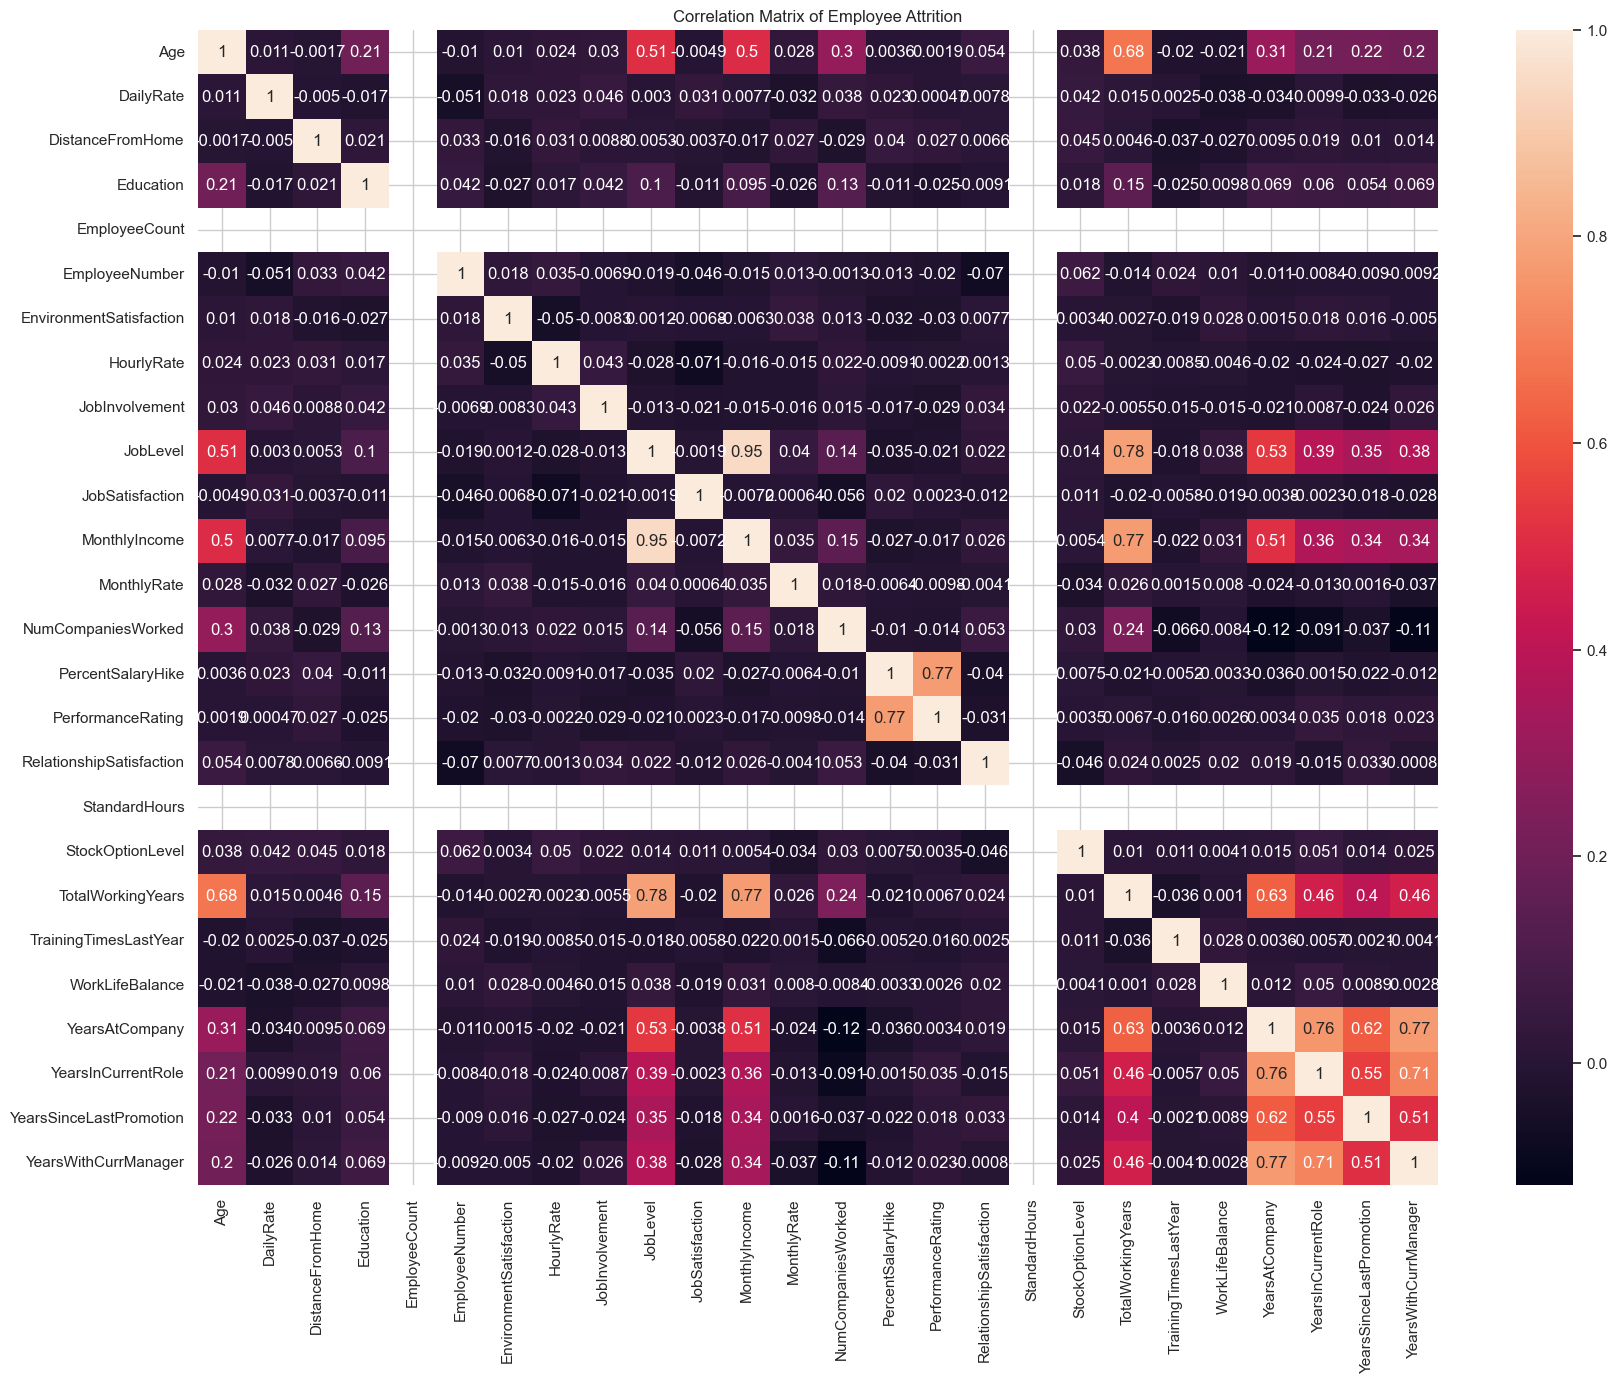

In [321]:
plt.figure(figsize=(20,15))
num_df = df.select_dtypes(['float64',"int64"])
correlation_matrix = num_df.corr()

sns.heatmap(correlation_matrix,annot=True)

plt.title("Correlation Matrix of Employee Attrition")
plt.show()

In [322]:
columns_to_drop = ["EmployeeCount","EmployeeNumber","Over18","StandardHours","DailyRate","HourlyRate","MonthlyRate","JobLevel"]

In [323]:
df.drop(columns_to_drop, axis=1, inplace=True)
df.drop_duplicates(inplace=True)

In [324]:
df

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,Sales,1,2,Life Sciences,2,Female,3,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,Research & Development,8,1,Life Sciences,3,Male,2,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,Research & Development,2,2,Other,4,Male,2,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,Research & Development,3,4,Life Sciences,4,Female,3,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,Research & Development,2,1,Medical,1,Male,3,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,Research & Development,23,2,Medical,3,Male,4,...,3,3,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,Research & Development,6,1,Medical,4,Male,2,...,3,1,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,Research & Development,4,3,Life Sciences,2,Male,4,...,4,2,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,Sales,2,3,Medical,4,Male,2,...,3,4,0,17,3,2,9,6,0,8


In [325]:
df.value_counts("Attrition")

Attrition
No     1233
Yes     237
Name: count, dtype: int64

# Data Visualization

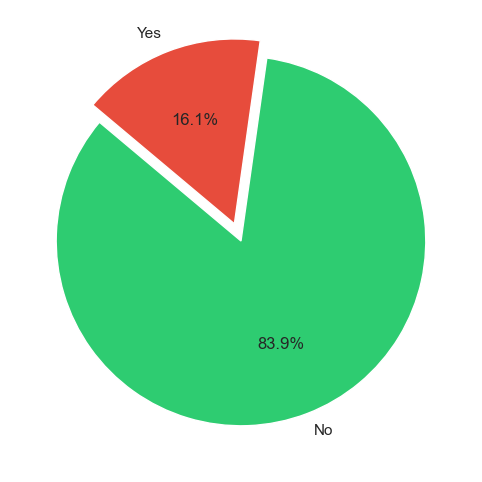

In [326]:
plt.figure(figsize=(8, 6))
attrition_counts = df['Attrition'].value_counts()
plt.pie(attrition_counts,
        labels=['No', 'Yes'],
        autopct='%1.1f%%',
        startangle=140,
        colors=['#2ecc71', '#e74c3c'],
        explode=(0, 0.1))
plt.show()

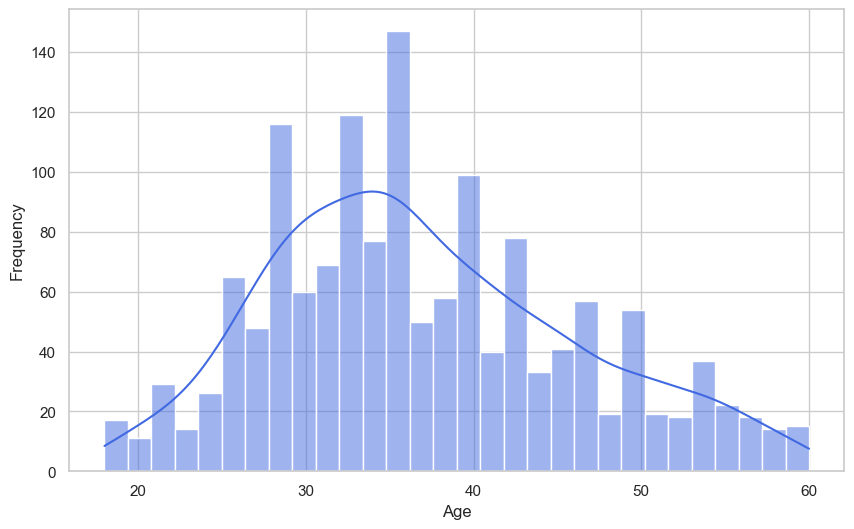

In [327]:
# Cell 2: Age Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, color='royalblue', bins=30)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

C:\Users\emre.seyhan\AppData\Local\Temp\ipykernel_19004\3200375127.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='EducationField', data=df, palette='magma', order=df['EducationField'].value_counts().index)


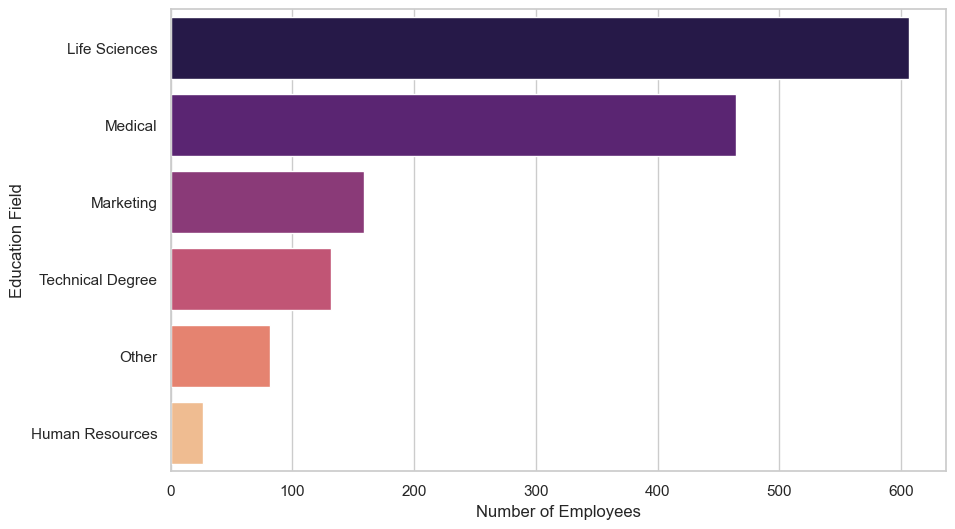

In [328]:
plt.figure(figsize=(10, 6))
sns.countplot(y='EducationField', data=df, palette='magma', order=df['EducationField'].value_counts().index)
plt.xlabel('Number of Employees')
plt.ylabel('Education Field')
plt.show()

C:\Users\emre.seyhan\AppData\Local\Temp\ipykernel_19004\1481014005.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='JobSatisfaction', data=df, palette='viridis')


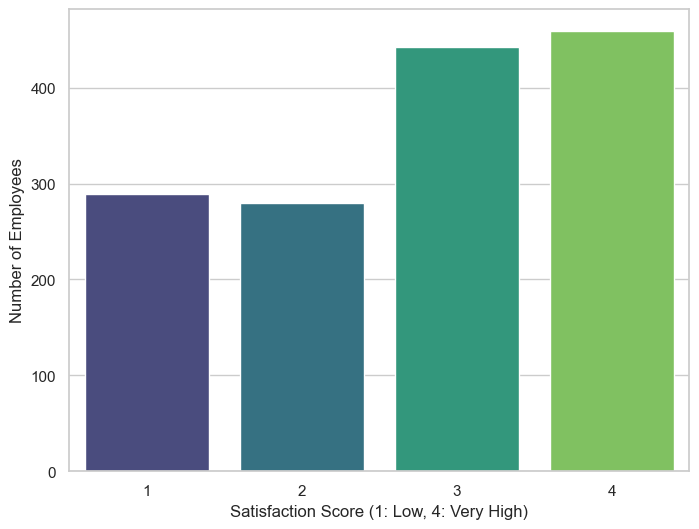

In [329]:
plt.figure(figsize=(8, 6))
sns.countplot(x='JobSatisfaction', data=df, palette='viridis')
plt.xlabel('Satisfaction Score (1: Low, 4: Very High)')
plt.ylabel('Number of Employees')
plt.show()

### The relationship between attrition and other columns

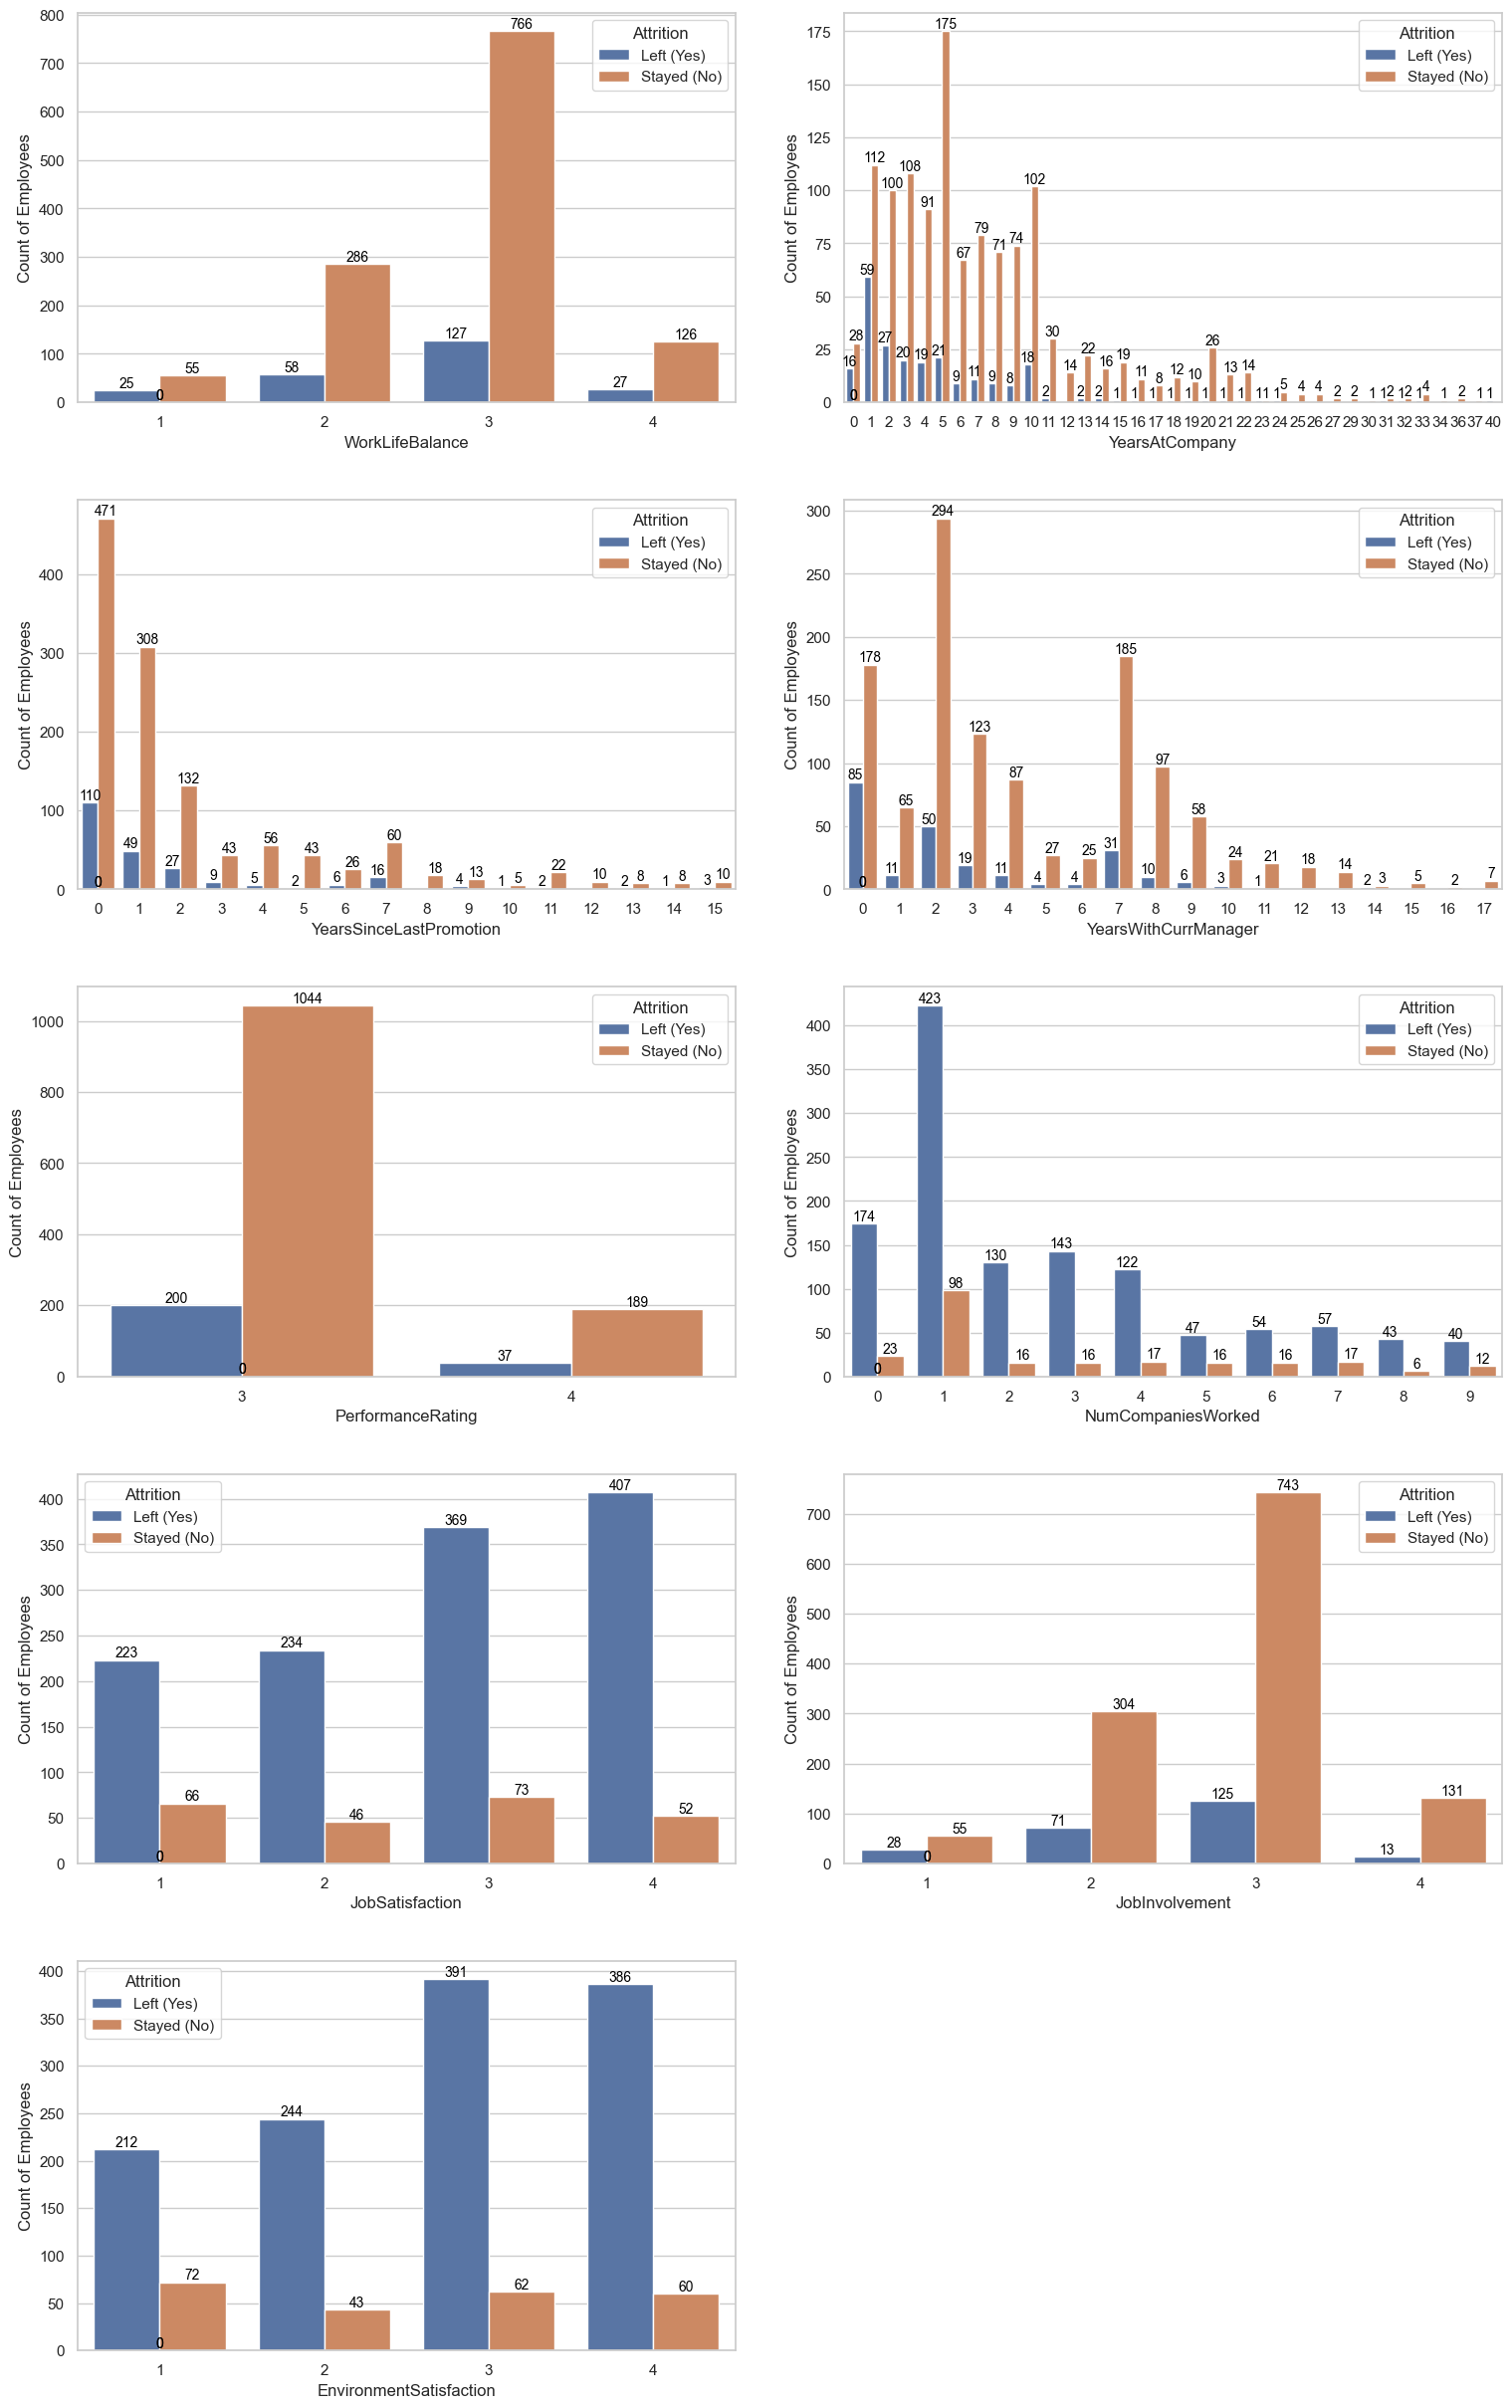

In [330]:
column_labels = [
    "WorkLifeBalance", "YearsAtCompany", "YearsSinceLastPromotion",
    "YearsWithCurrManager", "PerformanceRating", "NumCompaniesWorked", "JobSatisfaction", "JobInvolvement",
    "EnvironmentSatisfaction"
]

plt.figure(figsize=(16, 25))
for i, col in enumerate(column_labels):
    ax = plt.subplot(5, 2, i + 1)
    sns.countplot(x=col, hue="Attrition", data=df)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count of Employees', fontsize=12)
    plt.legend(title='Attrition', labels=['Left (Yes)', 'Stayed (No)'])
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')

plt.tight_layout(pad=3.0)
plt.show()

### Label encoding for non-numeric features in our dataset


In [331]:
le = LabelEncoder()
df["Attrition"] = le.fit_transform(df["Attrition"])
df["Gender"] = le.fit_transform(df["Gender"])
df["OverTime"] = le.fit_transform(df["OverTime"])

In [332]:
df = pd.get_dummies(df, columns=['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus'], drop_first=True)

In [333]:
df = df.astype(int)

In [334]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 41 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   Attrition                          1470 non-null   int64
 2   DistanceFromHome                   1470 non-null   int64
 3   Education                          1470 non-null   int64
 4   EnvironmentSatisfaction            1470 non-null   int64
 5   Gender                             1470 non-null   int64
 6   JobInvolvement                     1470 non-null   int64
 7   JobSatisfaction                    1470 non-null   int64
 8   MonthlyIncome                      1470 non-null   int64
 9   NumCompaniesWorked                 1470 non-null   int64
 10  OverTime                           1470 non-null   int64
 11  PercentSalaryHike                  1470 non-null   int64
 12  PerformanceRating              

In [335]:
df

,Age,Attrition,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,JobInvolvement,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1,2,2,0,3,4,5993,8,...,0,0,0,0,0,0,1,0,0,1
1,49,0,8,1,3,1,2,2,5130,1,...,0,0,0,0,0,1,0,0,1,0
2,37,1,2,2,4,1,2,3,2090,6,...,0,1,0,0,0,0,0,0,0,1
3,33,0,3,4,4,0,3,3,2909,1,...,0,0,0,0,0,1,0,0,1,0
4,27,0,2,1,1,1,3,2,3468,9,...,0,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,23,2,3,1,4,4,2571,4,...,0,1,0,0,0,0,0,0,1,0
1466,39,0,6,1,4,1,2,1,9991,4,...,0,0,0,0,0,0,0,0,1,0
1467,27,0,4,3,2,1,4,2,6142,1,...,0,0,0,1,0,0,0,0,1,0
1468,49,0,2,3,4,1,2,2,5390,2,...,0,0,0,0,0,0,1,0,1,0


In [336]:
def draw_confusion_matrix(c_matrix):
    sns.heatmap(c_matrix, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Real')
    plt.show()

# Model Training

In [337]:
y = df["Attrition"]
x = df.drop("Attrition", axis=1)

In [338]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Logistic Regression


In [339]:
lr = LogisticRegression()
lr.fit(x_train, y_train)

C:\Users\emre.seyhan\PycharmProjects\HR-Employee-Attrition\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [340]:
lr.score(x_test, y_test)

0.8605442176870748

In [341]:
y_predict = lr.predict(x_test)
y_predict

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0])

In [342]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.87      0.99      0.92       255
           1       0.25      0.03      0.05        39

    accuracy                           0.86       294
   macro avg       0.56      0.51      0.49       294
weighted avg       0.79      0.86      0.81       294



## Confusion Matrix

In [343]:
c_matrix = confusion_matrix(y_test, y_predict)
c_matrix

array([[252,   3],
       [ 38,   1]])

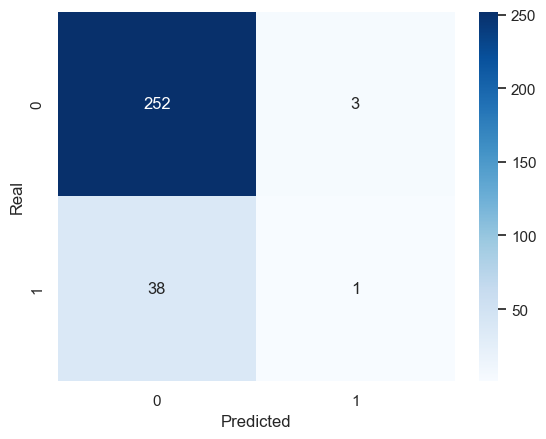

In [344]:
draw_confusion_matrix(c_matrix)

## Random Forest


In [345]:
rf = RandomForestClassifier()
rf.fit(x_train, y_train)
y_predict = rf.predict(x_test)

In [346]:
rf.score(x_test, y_test)


0.8775510204081632

In [347]:
c_matrix = confusion_matrix(y_test, y_predict)
c_matrix


array([[254,   1],
       [ 35,   4]])

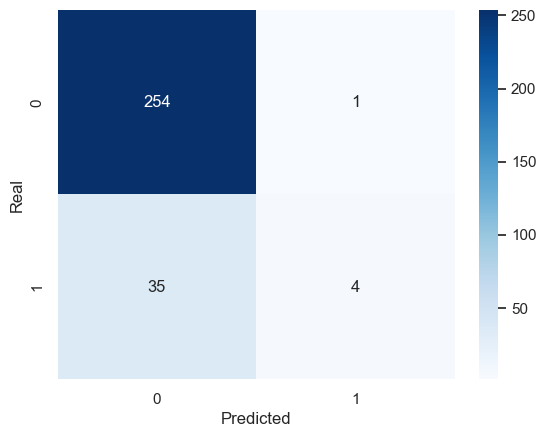

In [348]:
draw_confusion_matrix(c_matrix)


Synthetic data generation with SMOTE due to an extremely imbalanced resignation rate


In [349]:
smote = SMOTE(random_state=42)

x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

### Fit Logistic Regression Again

In [350]:
lr.fit(x_train_smote, y_train_smote)
y_predict = lr.predict(x_test)

C:\Users\emre.seyhan\PycharmProjects\HR-Employee-Attrition\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


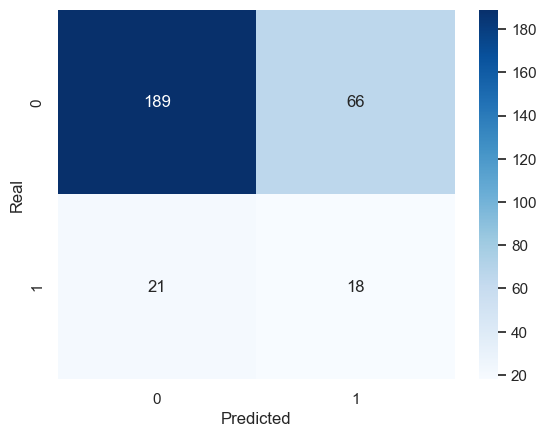

In [351]:
c_matrix = confusion_matrix(y_test, y_predict)
draw_confusion_matrix(c_matrix)

### Fit Random Forest Again

In [352]:
rf.fit(x_train_smote, y_train_smote)
y_predict = rf.predict(x_test)

### New confusion matrix for random forest

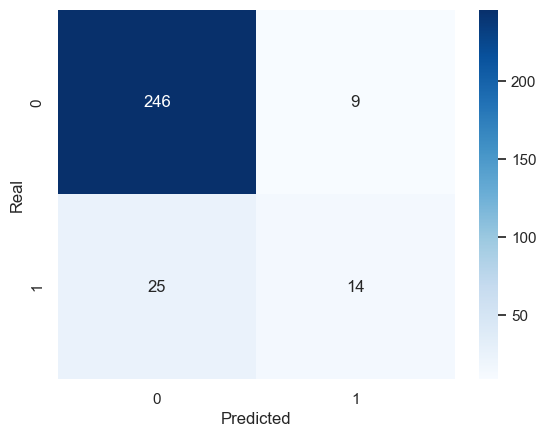

In [353]:
c_matrix = confusion_matrix(y_test, y_predict)
draw_confusion_matrix(c_matrix)

## XGBoost


In [359]:
xgb_model = xgb.XGBClassifier(n_estimators=200, max_depth=5, random_state=42)
xgb_model.fit(x_train_smote, y_train_smote)
xgb_model.score(x_test, y_test)

0.8537414965986394

In [360]:
confusion = confusion_matrix(y_test, y_predict)
confusion

array([[246,   9],
       [ 25,  14]])

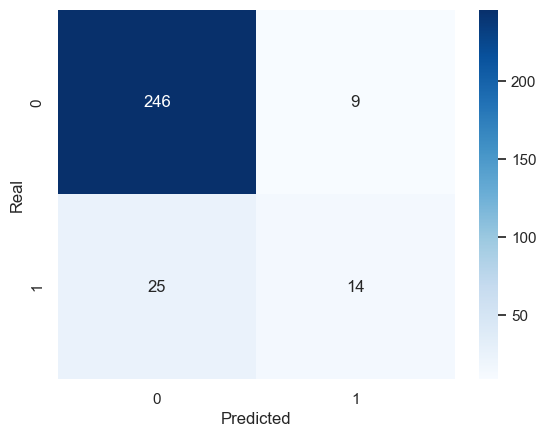

In [361]:
sns.heatmap(c_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Real')
plt.show()